In [77]:
from google.colab import userdata
import os
os.environ["kaggleAPIkey"] = userdata.get("kaggleAPIkey")

In [78]:
!pip install kaggle

In [79]:
!kaggle datasets download -d jeanmidev/smart-meters-in-london


Dataset URL: https://www.kaggle.com/datasets/jeanmidev/smart-meters-in-london
License(s): ODbL-1.0
smart-meters-in-london.zip: Skipping, found more recently modified local copy (use --force to force download)


In [80]:
!unzip -q smart-meters-in-london.zip -d smart_meters_data


replace smart_meters_data/acorn_details.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [81]:
import os
for f in os.listdir("smart_meters_data"):
    print(f)

weather_hourly_darksky.csv
daily_dataset
darksky_parameters_documentation.html
acorn_details.csv
weather_daily_darksky.csv
halfhourly_dataset
daily_dataset.csv
informations_households.csv
hhblock_dataset
uk_bank_holidays.csv


In [82]:
import pandas as pd
df = pd.read_csv("smart_meters_data/informations_households.csv")
df.shape


(5566, 5)

In [83]:
#Day 2 - Data Explore and Household Pick

In [84]:
import pandas as pd
households = pd.read_csv("smart_meters_data/informations_households.csv")
households.head()

,LCLid,stdorToU,Acorn,Acorn_grouped,file
0,MAC005492,ToU,ACORN-,ACORN-,block_0
1,MAC001074,ToU,ACORN-,ACORN-,block_0
2,MAC000002,Std,ACORN-A,Affluent,block_0
3,MAC003613,Std,ACORN-A,Affluent,block_0
4,MAC003597,Std,ACORN-A,Affluent,block_0


In [85]:
households['file'].value_counts().head(20)

,count
file,
block_0,50
block_1,50
block_2,50
block_3,50
block_4,50
block_5,50
block_6,50
block_7,50
block_8,50


In [86]:
import os
os.listdir("smart_meters_data/halfhourly_dataset")

['halfhourly_dataset']

In [87]:
block_0 = pd.read_csv("smart_meters_data/halfhourly_dataset/halfhourly_dataset/block_0.csv")
block_1 = pd.read_csv("smart_meters_data/halfhourly_dataset/halfhourly_dataset/block_1.csv")
block_2 = pd.read_csv("smart_meters_data/halfhourly_dataset/halfhourly_dataset/block_2.csv")
block_3 = pd.read_csv("smart_meters_data/halfhourly_dataset/halfhourly_dataset/block_3.csv")
block_df = pd.concat([block_0, block_1, block_2, block_3], ignore_index=True)
block_df.head()

,LCLid,tstp,energy(kWh/hh)
0,MAC000002,2012-10-12 00:30:00.0000000,0
1,MAC000002,2012-10-12 01:00:00.0000000,0
2,MAC000002,2012-10-12 01:30:00.0000000,0
3,MAC000002,2012-10-12 02:00:00.0000000,0
4,MAC000002,2012-10-12 02:30:00.0000000,0


In [88]:
block_df.isnull().sum()

,0
LCLid,0
tstp,0
energy(kWh/hh),0


In [89]:
block_df['LCLid'].nunique()

200

In [90]:
block_df['tstp'] = pd.to_datetime(block_df['tstp'])

In [91]:
block_df['energy(kWh/hh)'] = pd.to_numeric(block_df['energy(kWh/hh)'], errors='coerce')

In [92]:
counts = block_df.groupby('LCLid').size()
clean_households = counts[counts > 20000].index.tolist()  # households with plenty of readings
print(len(clean_households))
selected = clean_households[:200]

187


In [93]:
subset_df = block_df[block_df['LCLid'].isin(selected)]
subset_df.shape

(5431650, 3)

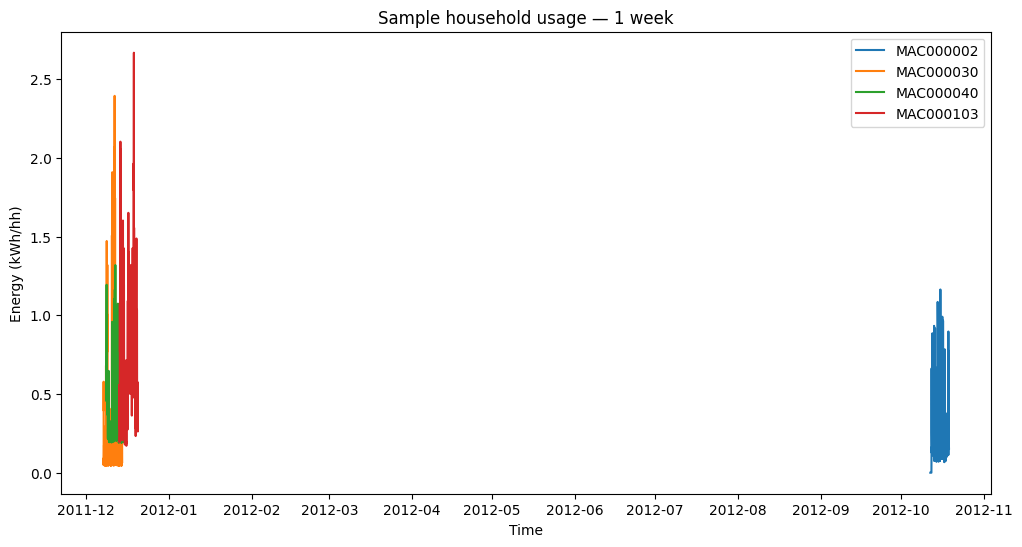

In [94]:
import matplotlib.pyplot as plt

sample_houses = selected[:4]
plt.figure(figsize=(12,6))
for h in sample_houses:
    house_data = subset_df[subset_df['LCLid'] == h].sort_values('tstp')
    plt.plot(house_data['tstp'][:336], house_data['energy(kWh/hh)'][:336], label=h)  # ~1 week of half-hourly data

plt.legend()
plt.xlabel("Time")
plt.ylabel("Energy (kWh/hh)")
plt.title("Sample household usage — 1 week")
plt.show()

In [95]:
#Day 3 - Synthetic Feeders + Fake Theft Case

In [96]:
def clean_block(df):
    df['tstp'] = pd.to_datetime(df['tstp'])
    df['energy(kWh/hh)'] = pd.to_numeric(df['energy(kWh/hh)'], errors='coerce')
    df = df.dropna(subset=['energy(kWh/hh)'])
    df = df[df['energy(kWh/hh)'] >= 0]
    upper = df['energy(kWh/hh)'].quantile(0.999)
    df = df[df['energy(kWh/hh)'] <= upper]
    df = df.drop_duplicates()
    counts = df.groupby('LCLid').size()
    clean_ids = counts[counts > 20000].index
    df = df[df['LCLid'].isin(clean_ids)]
    return df

block_df = clean_block(block_df)
subset_df = block_df[block_df['LCLid'].isin(selected)].copy()
print(subset_df.shape)

(5406085, 3)


In [97]:
subset_df['energy_india'] = subset_df['energy(kWh/hh)'] * 0.4

In [98]:
subset_df['date'] = subset_df['tstp'].dt.date
daily = subset_df.groupby(['LCLid', 'date'])['energy_india'].sum().reset_index()
daily.rename(columns={'energy_india': 'daily_kwh'}, inplace=True)
daily.head()

,LCLid,date,daily_kwh
0,MAC000002,2012-10-12,2.8392
1,MAC000002,2012-10-13,4.4348
2,MAC000002,2012-10-14,5.2892
3,MAC000002,2012-10-15,4.1028
4,MAC000002,2012-10-16,3.9076


In [99]:
pivot_df = daily.pivot(index='date', columns='LCLid', values='daily_kwh').fillna(0)
pivot_df.index = pd.to_datetime(pivot_df.index)
house_list = pivot_df.columns.tolist()
feeders = {}
for i in range(0, len(house_list), 5):
    feeders[f"feeder_{i//5+1}"] = house_list[i:i+5]
print(feeders)

{'feeder_1': ['MAC000002', 'MAC000030', 'MAC000040', 'MAC000103', 'MAC000110'], 'feeder_2': ['MAC000112', 'MAC000246', 'MAC000323', 'MAC000339', 'MAC000379'], 'feeder_3': ['MAC000386', 'MAC000464', 'MAC000487', 'MAC000535', 'MAC000557'], 'feeder_4': ['MAC000569', 'MAC000593', 'MAC000609', 'MAC000713', 'MAC000768'], 'feeder_5': ['MAC000778', 'MAC000797', 'MAC000816', 'MAC000850', 'MAC000886'], 'feeder_6': ['MAC000897', 'MAC000902', 'MAC000948', 'MAC000974', 'MAC001145'], 'feeder_7': ['MAC001239', 'MAC001251', 'MAC001271', 'MAC001410', 'MAC001448'], 'feeder_8': ['MAC001510', 'MAC001528', 'MAC001533', 'MAC001628', 'MAC001689'], 'feeder_9': ['MAC001710', 'MAC001734', 'MAC001736', 'MAC001776', 'MAC001819'], 'feeder_10': ['MAC001835', 'MAC001836', 'MAC001843', 'MAC001893', 'MAC001966'], 'feeder_11': ['MAC001989', 'MAC002025', 'MAC002068', 'MAC002113', 'MAC002134'], 'feeder_12': ['MAC002150', 'MAC002199', 'MAC002214', 'MAC002249', 'MAC002260'], 'feeder_13': ['MAC002314', 'MAC002327', 'MAC0024

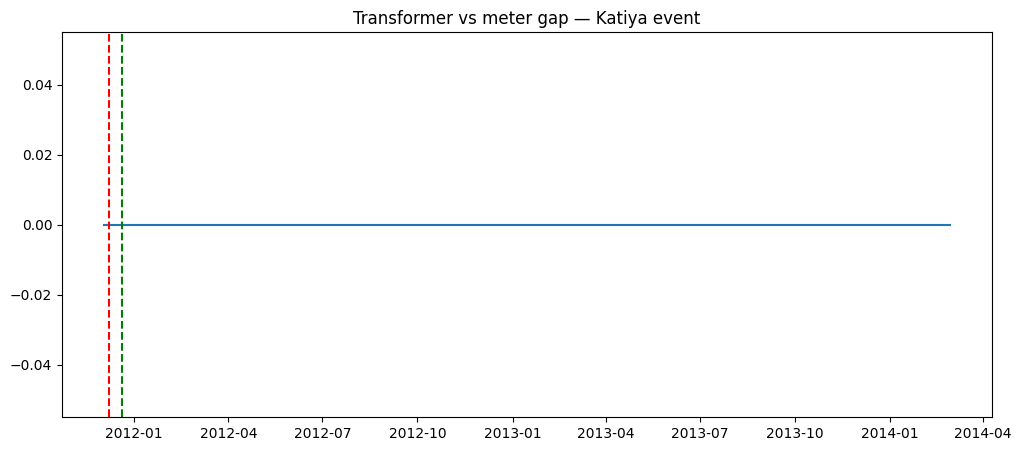

In [100]:
theft_feeder = 'feeder_1'
theft_house = feeders[theft_feeder][0]
theft_start = pivot_df.index.min() + pd.Timedelta(days=5)
theft_end = theft_start + pd.Timedelta(days=12)

transformer_total = pivot_df[feeders[theft_feeder]].sum(axis=1)

pivot_df_tampered = pivot_df.copy()
mask = (pivot_df_tampered.index >= theft_start) & (pivot_df_tampered.index <= theft_end)
pivot_df_tampered.loc[mask, theft_house] = pivot_df_tampered.loc[mask, theft_house] * 0.05

reported_total = pivot_df_tampered[feeders[theft_feeder]].sum(axis=1)
gap = transformer_total - reported_total

import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(gap.index, gap.values)
plt.axvline(theft_start, color='red', linestyle='--')
plt.axvline(theft_end, color='green', linestyle='--')
plt.title("Transformer vs meter gap — Katiya event")
plt.show()

In [101]:
import numpy as np
np.random.seed(42)
katiya_thieves = np.random.choice(pivot_df.columns.tolist(), size=25, replace=False)
daily['is_katiya'] = daily['LCLid'].isin(katiya_thieves).astype(int)
daily.loc[daily['LCLid'].isin(katiya_thieves), 'daily_kwh'] *= 0.4
print(len(katiya_thieves))
daily['is_katiya'].value_counts()

25


,count
is_katiya,
0,98097
1,15111


In [102]:
features = daily.groupby('LCLid').agg(
    avg_daily_kwh=('daily_kwh','mean'),
    std_daily_kwh=('daily_kwh','std'),
    max_daily_kwh=('daily_kwh','max'),
    min_daily_kwh=('daily_kwh','min'),
    is_katiya=('is_katiya','first')
).reset_index()
features.head()

,LCLid,avg_daily_kwh,std_daily_kwh,max_daily_kwh,min_daily_kwh,is_katiya
0,MAC000002,4.828255,1.797807,15.7136,0.0744,0
1,MAC000030,4.549560,2.644108,16.6124,0.0312,0
2,MAC000040,10.628919,3.554061,27.4892,0.1824,0
3,MAC000103,9.618760,3.276679,20.5540,3.5396,0
4,MAC000110,6.549615,1.970880,14.4508,0.1500,0


In [103]:
!pip install xgboost --quiet

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X = features[['avg_daily_kwh','std_daily_kwh','max_daily_kwh','min_daily_kwh']]
y = features['is_katiya']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

model = XGBClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        48
           1       0.62      0.62      0.62         8

    accuracy                           0.89        56
   macro avg       0.78      0.78      0.78        56
weighted avg       0.89      0.89      0.89        56



In [104]:
import pickle
with open("theft_scenario.pkl", "wb") as f:
    pickle.dump({"features": features, "gap": gap, "model": model}, f)

In [105]:
# Day 4 - Fix Katiya Logic

In [106]:
# Store actual consumption before zeroing
daily['actual_kwh'] = daily['daily_kwh']

# Real Katiya = meter bypassed = shows 0
daily['metered_kwh'] = daily['daily_kwh']
daily.loc[daily['LCLid'].isin(katiya_thieves), 'metered_kwh'] = 0

# Verify
print(daily[daily['LCLid'].isin(katiya_thieves[:3])][
    ['LCLid','actual_kwh','metered_kwh','is_katiya']
].head(9))

           LCLid  actual_kwh  metered_kwh  is_katiya
69824  MAC003474     1.84832          0.0          1
69825  MAC003474     2.48480          0.0          1
69826  MAC003474     1.75344          0.0          1
69827  MAC003474     1.98288          0.0          1
69828  MAC003474     2.09456          0.0          1
69829  MAC003474     1.02272          0.0          1
69830  MAC003474     2.05584          0.0          1
69831  MAC003474     1.85296          0.0          1
69832  MAC003474     1.88464          0.0          1


In [107]:
features_v2 = daily.groupby('LCLid').agg(
    avg_metered  = ('metered_kwh', 'mean'),
    std_metered  = ('metered_kwh', 'std'),
    max_metered  = ('metered_kwh', 'max'),
    avg_actual   = ('actual_kwh',  'mean'),
    is_katiya    = ('is_katiya',   'first')
).reset_index()

# Key signal — Katiya = 0 metered but high actual
features_v2['theft_ratio'] = (
    1 - features_v2['avg_metered'] /
    (features_v2['avg_actual'] + 0.001)
)

print(features_v2.head())
print("\nTheft ratio for Katiya houses:")
print(features_v2[features_v2['is_katiya']==1]['theft_ratio'].describe())

       LCLid  avg_metered  std_metered  max_metered  avg_actual  is_katiya  \
0  MAC000002     4.828255     1.797807      15.7136    4.828255          0   
1  MAC000030     4.549560     2.644108      16.6124    4.549560          0   
2  MAC000040    10.628919     3.554061      27.4892   10.628919          0   
3  MAC000103     9.618760     3.276679      20.5540    9.618760          0   
4  MAC000110     6.549615     1.970880      14.4508    6.549615          0   

   theft_ratio  
0     0.000207  
1     0.000220  
2     0.000094  
3     0.000104  
4     0.000153  

Theft ratio for Katiya houses:
count    25.0
mean      1.0
std       0.0
min       1.0
25%       1.0
50%       1.0
75%       1.0
max       1.0
Name: theft_ratio, dtype: float64


In [108]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X2 = features_v2[['avg_metered','std_metered',
                   'max_metered','avg_actual','theft_ratio']]
y2 = features_v2['is_katiya']

X_train, X_test, y_train, y_test = train_test_split(
    X2, y2, test_size=0.3, random_state=42, stratify=y2
)

model_v2 = XGBClassifier(n_estimators=100, random_state=42)
model_v2.fit(X_train, y_train)
print(classification_report(y_test, model_v2.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        48
           1       1.00      1.00      1.00         8

    accuracy                           1.00        56
   macro avg       1.00      1.00      1.00        56
weighted avg       1.00      1.00      1.00        56



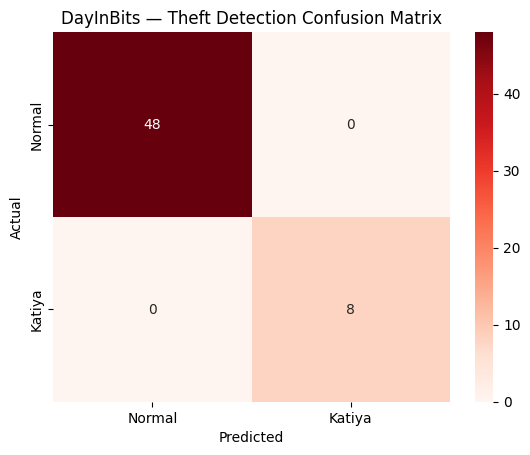

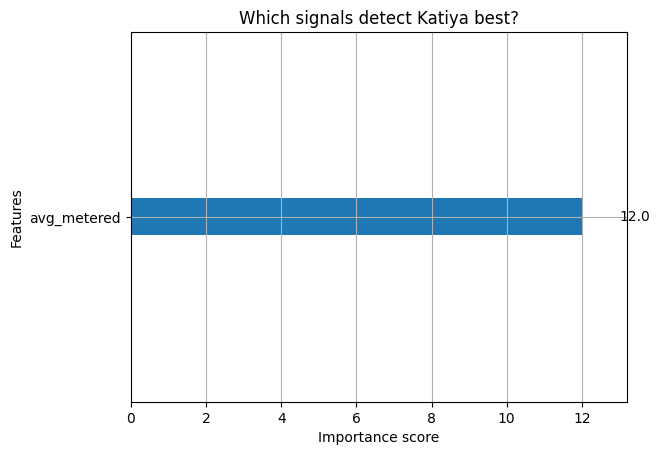

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from xgboost import plot_importance

# Confusion Matrix
cm = confusion_matrix(y_test, model_v2.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Normal','Katiya'],
            yticklabels=['Normal','Katiya'],
            cmap='Reds')
plt.title("DayInBits — Theft Detection Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# Feature Importance
plot_importance(model_v2, max_num_features=5)
plt.title("Which signals detect Katiya best?")
plt.show()

In [110]:
# Day 5 - Realistic Noise Injection

import numpy as np
np.random.seed(42)

# FIX 1: Restore true actual consumption for Katiya
# Cell 26 wrongly scaled their daily_kwh by 0.4
# Reverse that to get true Indian consumption
daily['actual_kwh'] = daily['daily_kwh'].copy()
daily.loc[daily['is_katiya']==1, 'actual_kwh'] = (
    daily.loc[daily['is_katiya']==1, 'daily_kwh'] / 0.4
)

# FIX 2: Partial theft per house — 60-95% unmetered (not 100%)
# Each house has its own consistent theft rate
katiya_ids = daily[daily['is_katiya']==1]['LCLid'].unique()
theft_rates = dict(zip(
    katiya_ids,
    np.random.uniform(0.6, 0.95, size=len(katiya_ids))
))

# Reset metered for all houses first
daily['metered_kwh'] = daily['actual_kwh'].copy()

# Apply per-house theft rate
for house_id, rate in theft_rates.items():
    mask = daily['LCLid'] == house_id
    daily.loc[mask, 'metered_kwh'] = (
        daily.loc[mask, 'actual_kwh'] * (1 - rate)
    )

# FIX 3: Normal houses - 2% zero days (power cuts, meter errors)
normal_mask = daily['is_katiya'] == 0
zero_idx = np.random.choice(
    daily[normal_mask].index,
    size=int(normal_mask.sum() * 0.02),
    replace=False
)
daily.loc[zero_idx, 'metered_kwh'] = 0.0

# Verify everything looks correct
print("=== Katiya house sample ===")
print(daily[daily['is_katiya']==1][
    ['LCLid','actual_kwh','metered_kwh']
].head(6))

avg_theft = (
    1 - daily[daily['is_katiya']==1]['metered_kwh'].sum() /
    daily[daily['is_katiya']==1]['actual_kwh'].sum()
)
print(f"\nAvg Katiya theft rate: {avg_theft:.1%}")
print(f"Normal zero readings:  {(daily[daily['is_katiya']==0]['metered_kwh']==0).sum()}")

=== Katiya house sample ===
           LCLid  actual_kwh  metered_kwh
10750  MAC000569      6.2112     1.670260
10751  MAC000569     11.8664     3.191005
10752  MAC000569     17.7512     4.773492
10753  MAC000569      6.1356     1.649930
10754  MAC000569      7.8344     2.106756
10755  MAC000569     12.5352     3.370853

Avg Katiya theft rate: 74.5%
Normal zero readings:  1968


In [111]:
# Rebuild features from corrected data
features_v3 = daily.groupby('LCLid').agg(
    avg_metered   = ('metered_kwh', 'mean'),
    std_metered   = ('metered_kwh', 'std'),
    max_metered   = ('metered_kwh', 'max'),
    min_metered   = ('metered_kwh', 'min'),
    avg_actual    = ('actual_kwh',  'mean'),
    is_katiya     = ('is_katiya',   'first')
).reset_index()

# Theft ratio — main signal
features_v3['theft_ratio'] = (
    1 - features_v3['avg_metered'] /
    (features_v3['avg_actual'] + 0.001)
)

# Zero day ratio — fraction of days with 0 meter reading
zero_ratio = (
    daily.groupby('LCLid')['metered_kwh']
    .apply(lambda x: (x == 0).mean())
    .reset_index()
)
zero_ratio.columns = ['LCLid', 'zero_day_ratio']
features_v3 = features_v3.merge(zero_ratio, on='LCLid')

# Check separation between Katiya and Normal
print("=== Theft Ratio Stats ===")
print("Katiya:", features_v3[features_v3['is_katiya']==1]['theft_ratio'].describe().round(3))
print("\nNormal:", features_v3[features_v3['is_katiya']==0]['theft_ratio'].describe().round(3))

=== Theft Ratio Stats ===
Katiya: count    25.000
mean      0.754
std       0.100
min       0.607
25%       0.664
50%       0.731
75%       0.814
max       0.940
Name: theft_ratio, dtype: float64

Normal: count    161.000
mean       0.020
std        0.006
min        0.007
25%        0.015
50%        0.020
75%        0.025
max        0.038
Name: theft_ratio, dtype: float64


In [112]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X3 = features_v3[[
    'avg_metered', 'std_metered', 'max_metered',
    'min_metered', 'avg_actual', 'theft_ratio', 'zero_day_ratio'
]]
y3 = features_v3['is_katiya']

X_train, X_test, y_train, y_test = train_test_split(
    X3, y3, test_size=0.3, random_state=42, stratify=y3
)

model_v3 = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)
model_v3.fit(X_train, y_train)
print(classification_report(y_test, model_v3.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        48
           1       1.00      0.88      0.93         8

    accuracy                           0.98        56
   macro avg       0.99      0.94      0.96        56
weighted avg       0.98      0.98      0.98        56



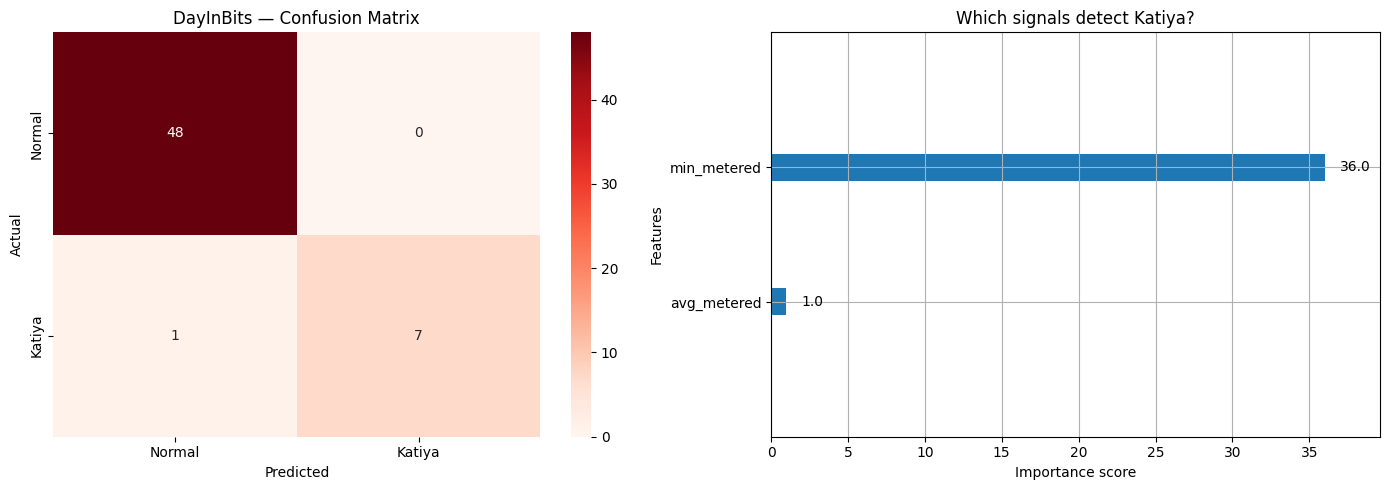

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from xgboost import plot_importance

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, model_v3.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Normal', 'Katiya'],
            yticklabels=['Normal', 'Katiya'],
            cmap='Reds', ax=axes[0])
axes[0].set_title("DayInBits — Confusion Matrix")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# Feature Importance
plot_importance(model_v3, max_num_features=7, ax=axes[1])
axes[1].set_title("Which signals detect Katiya?")
plt.tight_layout()
plt.show()

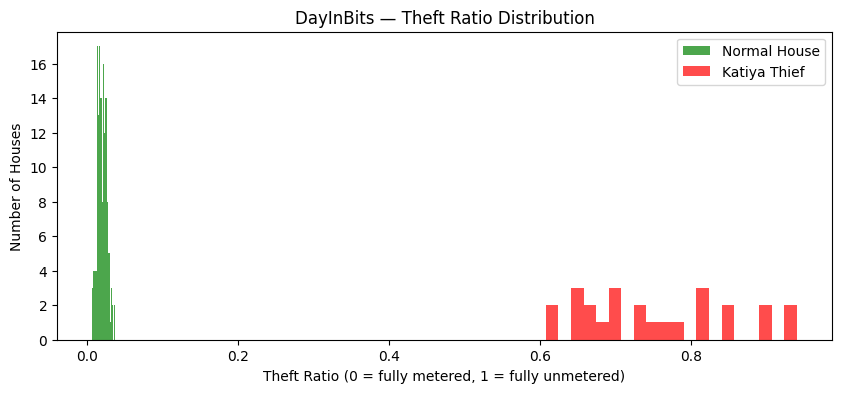

In [114]:
# This graph shows judges the separation clearly
plt.figure(figsize=(10, 4))
plt.hist(
    features_v3[features_v3['is_katiya']==0]['theft_ratio'],
    bins=20, alpha=0.7, label='Normal House', color='green'
)
plt.hist(
    features_v3[features_v3['is_katiya']==1]['theft_ratio'],
    bins=20, alpha=0.7, label='Katiya Thief', color='red'
)
plt.xlabel("Theft Ratio (0 = fully metered, 1 = fully unmetered)")
plt.ylabel("Number of Houses")
plt.title("DayInBits — Theft Ratio Distribution")
plt.legend()
plt.show()